# Cross-layer EDA 07: Feature engineering audit

This notebook remains **exploratory data analysis**. Its purpose is to decide which possible gene-pair features have a clear biological meaning, a correct denominator, and enough data quality to carry forward. It does not create a final answer key, train a model, rank pairs, or produce a probability.

## Questions

1. Which PRISM drug-response examples behave consistently with their proposed biology?
2. Which drug results are gene-specific enough to use as external support, and which are broad pathway effects?
3. Do the new TCGA mutation, copy-number, RNA, and structural-variant layers support tumour-level checks?
4. Which candidate features should be kept, kept with a warning, reserved for validation, or rejected?

## Biological references used for the audit

- [Vassilev et al. (2004)](https://pubmed.ncbi.nlm.nih.gov/14704432/) showed that blocking MDM2 can reactivate p53 signalling. This makes TP53 state essential context for interpreting MDM2 inhibitors.
- [Farmer et al. (2005)](https://pubmed.ncbi.nlm.nih.gov/15829967/) showed that BRCA1/2 dysfunction sensitises cells to PARP inhibition, providing the classic synthetic-lethality example.
- [Bitler et al. (2015)](https://www.nature.com/articles/nm.3799) reported an ARID1A-EZH2 synthetic-lethal relationship.
- [Terrell et al. (2022)](https://pubmed.ncbi.nlm.nih.gov/35139374/) showed that some KRAS-mutant tumours depend on RAF1/CRAF functions that are not fully reproduced by kinase inhibition. This is an important warning when comparing RAF1 knockout with broad RAF drugs.
- [Corsello et al. (2020)](https://pubmed.ncbi.nlm.nih.gov/32613204/) describes the PRISM pooled drug screen used here.
- TCGA PanCancer Atlas molecular data were acquired from the [cBioPortal public API](https://www.cbioportal.org/api/swagger-ui/index.html) using consistent studies listed by the [cBioPortal DataHub](https://github.com/cBioPortal/datahub).

## Guardrails

- Use `model_id` as the only automatic cell-line join key.
- Keep DepMap, PRISM, and TCGA as different biological cohorts and releases.
- Use actual assay-specific denominators. An absent mutation or fusion event is a measured negative only when the sample is in that assay's sample list.
- Analyse primary tumours separately from metastatic and recurrent samples.
- Keep mutation, copy-number, RNA, direct-fusion, codependency, conditional-dependency, drug, and knowledge-source evidence as separate routes.
- Treat PRISM and TCGA as external corroboration or context, not as hidden training labels.
- Do not turn missing evidence into zero.


In [1]:
from pathlib import Path
import gzip
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 180)
pd.set_option('display.max_rows', 180)
sns.set_theme(style='whitegrid', context='notebook')


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')


def canonical_pair(gene_a: str, gene_b: str) -> str:
    return '--'.join(sorted([str(gene_a).upper(), str(gene_b).upper()]))


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
CORE = PROJECT_ROOT / 'data' / 'depmap_24Q4'
EXT = PROJECT_ROOT / 'data' / 'external'
TCGA = EXT / 'tcga_cbioportal'
PATHS = {
    'master': CORE / 'architecture' / 'model_master.csv',
    'gene_master': CORE / 'architecture' / 'gene_master.csv',
    'effect': CORE / 'raw' / 'CRISPRGeneEffect.csv',
    'mutations': CORE / 'derived' / 'mutations_default_dna_gene_summary.csv',
    'prism_response': EXT / 'prism_repurposing' / 'raw' / 'primary-screen-replicate-collapsed-logfold-change.csv',
    'prism_treatments': EXT / 'prism_repurposing' / 'derived' / 'prism_treatment_catalog.csv',
    'tcga_acquisition': TCGA / 'tcga_panel_acquisition_manifest.json',
    'tcga_studies': TCGA / 'derived' / 'tcga_pancan_panel_study_manifest.csv',
    'tcga_samples': TCGA / 'derived' / 'tcga_pancan_panel_samples.csv',
    'tcga_mutations': TCGA / 'derived' / 'tcga_pancan_panel_mutations.csv',
    'tcga_cna': TCGA / 'derived' / 'tcga_pancan_panel_cna.csv',
    'tcga_rna': TCGA / 'derived' / 'tcga_pancan_panel_rna.csv',
    'tcga_sv': TCGA / 'derived' / 'tcga_pancan_panel_structural_variants.csv',
}

master = pd.read_csv(PATHS['master'], low_memory=False)
gene_master = pd.read_csv(PATHS['gene_master'], low_memory=False)
depmap_mutations = pd.read_csv(PATHS['mutations'], low_memory=False)
prism_treatments = pd.read_csv(PATHS['prism_treatments'], low_memory=False)
tcga_studies = pd.read_csv(PATHS['tcga_studies'], low_memory=False)
tcga_samples = pd.read_csv(PATHS['tcga_samples'], low_memory=False)
tcga_mutations = pd.read_csv(PATHS['tcga_mutations'], low_memory=False)
tcga_cna = pd.read_csv(PATHS['tcga_cna'], low_memory=False)
tcga_rna = pd.read_csv(PATHS['tcga_rna'], low_memory=False)
tcga_sv = pd.read_csv(PATHS['tcga_sv'], low_memory=False)
with open(PATHS['tcga_acquisition'], encoding='utf-8') as handle:
    tcga_acquisition = json.load(handle)

assert master['model_id'].is_unique
assert gene_master['symbol'].is_unique
master['oncotree_lineage'] = master['oncotree_lineage'].fillna('Unknown')
lineage_lookup = master.set_index('model_id')['oncotree_lineage']
gene_lookup = gene_master.set_index('symbol')

print(f"DepMap models: {len(master):,}")
print(f"PRISM treatment records: {len(prism_treatments):,}")
print(f"TCGA PanCancer Atlas studies: {len(tcga_studies):,}")
print(f"TCGA samples: {tcga_samples['sample_id'].nunique():,}")
print(f"TCGA panel genes: {len(tcga_acquisition['genes']):,}")


DepMap models: 2,105
PRISM treatment records: 4,686
TCGA PanCancer Atlas studies: 32
TCGA samples: 10,967
TCGA panel genes: 26


## Column dictionary

| Column | Meaning in simple terms | Project use |
|---|---|---|
| `model_id` | Stable DepMap identifier for one cell-line model. | Only automatic cell-line join key. |
| `study_id`, `sample_id` | TCGA cancer-cohort and tumour-sample identifiers. | Define tumour cohorts; never joined directly to a cell line. |
| `layer` | Mutation, discrete CNA, RSEM RNA, or structural-variant assay. | Keeps different biological measurements separate. |
| `measured_primary_samples` | Primary tumour samples listed as measured for that assay. | Correct denominator for event prevalence. |
| `mutationType` | Consequence of an observed DNA sequence change. | Separates any protein-altering event from stronger loss-of-function proxies. |
| `any_protein_altering` | Any mutation event in this panel table. | Broad mutation-context prevalence; not automatically a damaging mutation. |
| `truncating_or_splice` | Nonsense, frameshift, splice-site, start-loss, or nonstop event. | More specific proxy for loss of gene function. |
| `value` in CNA | GISTIC call: `-2`, `-1`, `0`, `1`, or `2`. | Deep deletion, shallow loss, neutral, gain, or amplification. It is not absolute copy number. |
| `value` in RNA | RSEM gene-expression quantity within a TCGA study. | Ranked within each study before pair correlation. |
| `exact_sv_pair` | Canonical pair made from both structural-variant gene endpoints. | Tests recurrence of an exact fusion/structural-variant pair in tumours. |
| `sv_positive_samples` | Measured primary tumours carrying the exact pair. | Tumour event numerator. |
| `tumour_prevalence_pct` | Event-positive samples divided by measured samples. | External tumour recurrence/context evidence. |
| `treatment_id` | Exact PRISM compound, dose, and screen condition. | Prevents different chemical conditions being merged. |
| `n_annotated_targets` | Number of genes listed as targets for a PRISM treatment. | Warning that a drug response may not be attributable to one gene. |
| `lineage_adjusted_genetic_drug_rho` | Correlation between CRISPR effect and drug response after removing broad lineage medians. | Checks whether a drug behaves somewhat like genetic loss of its stated target. |
| `lineage_adjusted_context_shift` | Difference in drug sensitivity between a biological context and reference group after lineage adjustment. | Positive means the pre-specified context group is more drug-sensitive. |
| `within_study_rna_rho` | Spearman correlation of two genes across tumours in one study. | Tumour co-expression context; not proof of direct interaction. |
| `audit_status` | `keep`, `keep_with_warning`, `external_validation_only`, `explanation_only`, `coverage_only`, or `do_not_use`. | Controls how a feature may enter later architecture. |
| `missing_state` | Meaning of a missing value for that feature. | Prevents unmeasured evidence from becoming a biological zero. |
| `leakage_risk` | How the feature could accidentally reveal or duplicate a future label. | Must be resolved before modelling. |


## 1. TCGA acquisition and denominator audit

Mutation and structural-variant files contain observed events, not one row for every measured negative sample. We therefore read each study's cBioPortal sample lists and intersect them with primary tumour samples. CNA and RNA have sample-gene rows, but their sample lists are still audited for consistency.


,table,rows,duplicate_grain_rows,grain
0,samples,10967,0,study x sample
1,mutations,7003,0,observed mutation event
2,discrete CNA,278512,0,study x sample x gene
3,RSEM RNA,261635,0,study x sample x gene
4,structural variants,546,0,observed structural-variant event


,samples
sample_type,
Primary Solid Tumor,10390
Metastatic,368
Primary Blood Tumor,200
Recurrent Solid Tumor,9


,sum,min,median,max
layer,,,,
cna,10345,0,288.0,1070
mutation,10070,36,283.5,1066
rna,9696,36,268.0,1082
structural_variant,10018,36,283.5,1066


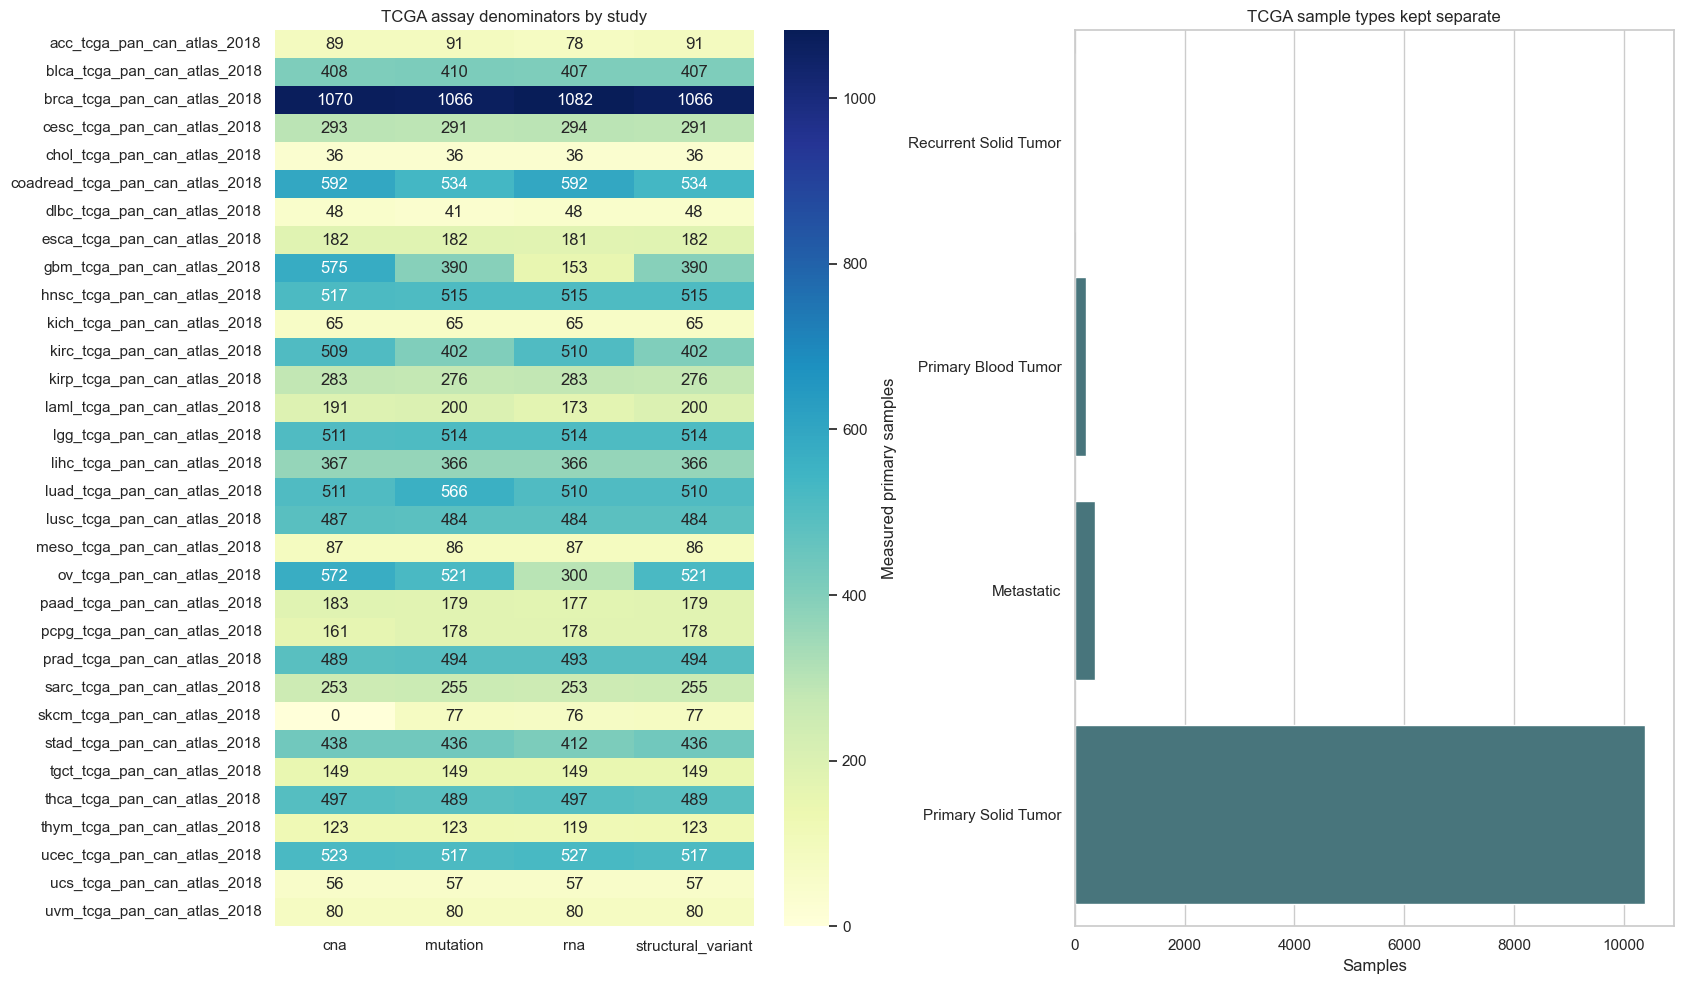

In [2]:
primary_types = {'Primary Solid Tumor', 'Primary Blood Tumor'}
primary_samples = tcga_samples.loc[tcga_samples['sample_type'].isin(primary_types)].copy()
primary_ids_by_study = primary_samples.groupby('study_id')['sample_id'].apply(set).to_dict()

layer_list_columns = {
    'mutation': 'mutation_sample_list_id',
    'cna': 'cna_sample_list_id',
    'rna': 'rna_sample_list_id',
    'structural_variant': 'sv_sample_list_id',
}
measured_sets = {}
denominator_rows = []
for study in tcga_studies.itertuples(index=False):
    sample_list_path = TCGA / 'raw' / study.study_id / 'sample_lists.json.gz'
    with gzip.open(sample_list_path, 'rt', encoding='utf-8') as handle:
        sample_lists = {row['sampleListId']: set(row.get('sampleIds', [])) for row in json.load(handle)}
    primary_ids = primary_ids_by_study.get(study.study_id, set())
    for layer, list_column in layer_list_columns.items():
        sample_list_id = getattr(study, list_column)
        all_measured = sample_lists.get(sample_list_id, set())
        measured_primary = all_measured & primary_ids
        measured_sets[(study.study_id, layer)] = measured_primary
        denominator_rows.append({
            'study_id': study.study_id,
            'study_name': study.study_name,
            'layer': layer,
            'sample_list_id': sample_list_id,
            'measured_all_samples': len(all_measured),
            'measured_primary_samples': len(measured_primary),
            'primary_samples_in_study': len(primary_ids),
        })
denominators = pd.DataFrame(denominator_rows)

integrity = pd.DataFrame([
    {'table': 'samples', 'rows': len(tcga_samples), 'duplicate_grain_rows': int(tcga_samples.duplicated(['study_id', 'sample_id']).sum()), 'grain': 'study x sample'},
    {'table': 'mutations', 'rows': len(tcga_mutations), 'duplicate_grain_rows': int(tcga_mutations.duplicated().sum()), 'grain': 'observed mutation event'},
    {'table': 'discrete CNA', 'rows': len(tcga_cna), 'duplicate_grain_rows': int(tcga_cna.duplicated(['study_id', 'sample_id', 'gene_symbol']).sum()), 'grain': 'study x sample x gene'},
    {'table': 'RSEM RNA', 'rows': len(tcga_rna), 'duplicate_grain_rows': int(tcga_rna.duplicated(['study_id', 'sample_id', 'gene_symbol']).sum()), 'grain': 'study x sample x gene'},
    {'table': 'structural variants', 'rows': len(tcga_sv), 'duplicate_grain_rows': int(tcga_sv.duplicated().sum()), 'grain': 'observed structural-variant event'},
])
display(integrity)
display(tcga_samples['sample_type'].value_counts().rename_axis('sample_type').to_frame('samples'))
display(denominators.groupby('layer')['measured_primary_samples'].agg(['sum', 'min', 'median', 'max']).round(1))

coverage_heatmap = denominators.pivot(index='study_id', columns='layer', values='measured_primary_samples')
fig, axes = plt.subplots(1, 2, figsize=(17, 10))
sns.heatmap(coverage_heatmap, cmap='YlGnBu', annot=True, fmt='.0f', cbar_kws={'label': 'Measured primary samples'}, ax=axes[0])
axes[0].set_title('TCGA assay denominators by study'); axes[0].set_xlabel(''); axes[0].set_ylabel('')
sample_type_counts = tcga_samples['sample_type'].value_counts().sort_values()
sns.barplot(x=sample_type_counts.values, y=sample_type_counts.index, color='#3f7c85', ax=axes[1])
axes[1].set_title('TCGA sample types kept separate'); axes[1].set_xlabel('Samples'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

assert len(tcga_studies) == 32
assert integrity['duplicate_grain_rows'].eq(0).all()
assert denominators.groupby('study_id')['layer'].nunique().eq(4).all()


### What this means for the project

All 32 selected TCGA PanCancer Atlas studies have mutation, CNA, RNA, and structural-variant profiles, but each assay can measure a slightly different set of samples. A mutation prevalence of 10% must therefore mean 10 mutation-positive primary tumours out of 100 mutation-measured primary tumours, not 10 out of every patient in the clinical table. Most records are primary tumours; metastatic and recurrent samples remain available but are not mixed into this audit because their biology and treatment history can differ.


## 2. Biological review of PRISM drug-response examples

Four mechanisms are reviewed because they illustrate different levels of evidence:

- **TP53/MDM2:** a useful positive-control mechanism. MDM2 inhibition usually needs functioning p53 signalling.
- **BRCA1 or BRCA2/PARP1:** established synthetic lethality, but the PRISM target list includes both clinically recognisable PARP inhibitors and weak or non-specific probes.
- **ARID1A/EZH2:** a published synthetic-lethal hypothesis, but an epigenetic inhibitor may need longer exposure than a primary viability screen provides.
- **KRAS/RAF1:** genetic RAF1 loss and RAF kinase inhibition are not equivalent. Many listed compounds hit BRAF, MEK, or numerous other kinases.

Lower PRISM log2 fold-change and lower CRISPR gene effect both mean stronger loss of viability. Their correlation should therefore be positive when chemical and genetic perturbation affect the same vulnerable models.


,hypothesis,biological_review_category,treatment_conditions,evaluable_context_shifts,positive_context_shifts,median_context_shift,median_genetic_drug_rho
0,ARID1A-altered -> EZH2 inhibitor,keep with strong warning,2,2,0,-0.081738,0.013358
1,ARID1A-altered -> EZH2 inhibitor,mechanistically informative,4,4,3,0.040384,0.069415
2,BRCA1-altered -> PARP1 inhibitor,exploratory PARP probe,7,7,3,-0.001318,0.040515
3,BRCA1-altered -> PARP1 inhibitor,mechanistically informative,5,5,4,0.096034,0.029525
4,BRCA1-altered -> PARP1 inhibitor,not a clean PARP validation probe,4,4,4,0.121405,0.037073
5,BRCA2-altered -> PARP1 inhibitor,exploratory PARP probe,7,7,4,0.011077,0.040515
6,BRCA2-altered -> PARP1 inhibitor,mechanistically informative,5,5,4,0.063973,0.029525
7,BRCA2-altered -> PARP1 inhibitor,not a clean PARP validation probe,4,4,2,0.063252,0.037073
8,KRAS-altered -> RAF1 inhibitor,"pathway-level, not RAF1-specific",11,11,7,0.006709,-0.007189
9,TP53-functional proxy -> MDM2 inhibitor,keep with strong warning,3,3,2,0.010105,0.036395


,hypothesis,context_definition,expected_direction,target_gene,drug_name,dose,treatment_id,moa,annotated_targets,n_annotated_targets,biological_review_category,biological_reason,shared_models,lineage_adjusted_models,lineage_adjusted_genetic_drug_rho,context_models,reference_models,lineage_adjusted_context_shift,observed_direction
43,ARID1A-altered -> EZH2 inhibitor,damaging/driver ARID1A event,altered more sensitive,EZH2,3-deazaneplanocin-A,2.500000,BRD-K77791657-001-01-1::2.5::HTS,histone lysine methyltransferase inhibitor,EZH2,1,keep with strong warning,indirect or broad epigenetic compound,465,438,0.013968,74,455,-0.076283,opposes expected sensitivity direction
44,ARID1A-altered -> EZH2 inhibitor,damaging/driver ARID1A event,altered more sensitive,EZH2,3-deazaneplanocin-A,2.670000,BRD-K77791657-003-01-7::2.67::HTS,histone lysine methyltransferase inhibitor,EZH2,1,keep with strong warning,indirect or broad epigenetic compound,437,411,0.012748,66,431,-0.087194,opposes expected sensitivity direction
39,ARID1A-altered -> EZH2 inhibitor,damaging/driver ARID1A event,altered more sensitive,EZH2,tazemetostat,2.310000,BRD-K11215326-001-03-7::2.31::HTS,histone lysine methyltransferase inhibitor,EZH2,1,mechanistically informative,direct EZH2 inhibitor; screen duration remains...,437,411,0.118192,66,431,0.078132,supports expected sensitivity direction
40,ARID1A-altered -> EZH2 inhibitor,damaging/driver ARID1A event,altered more sensitive,EZH2,GSK2816126,2.500000,BRD-K21867462-001-02-9::2.5::HTS,histone lysine methyltransferase inhibitor,EZH2,1,mechanistically informative,direct EZH2 inhibitor; screen duration remains...,459,432,0.086558,73,448,0.053777,supports expected sensitivity direction
42,ARID1A-altered -> EZH2 inhibitor,damaging/driver ARID1A event,altered more sensitive,EZH2,EPZ005687,2.500000,BRD-K57754230-001-02-7::2.5::HTS,histone lysine methyltransferase inhibitor,EZH2,1,mechanistically informative,direct EZH2 inhibitor; screen duration remains...,465,438,0.052273,74,455,0.026992,supports expected sensitivity direction
41,ARID1A-altered -> EZH2 inhibitor,damaging/driver ARID1A event,altered more sensitive,EZH2,UNC1999,2.500000,BRD-K26989966-001-03-5::2.5::HTS,histone lysine methyltransferase inhibitor,EZH2,1,mechanistically informative,direct EZH2 inhibitor; screen duration remains...,462,444,0.014003,74,460,-0.004052,opposes expected sensitivity direction
10,BRCA1-altered -> PARP1 inhibitor,damaging/driver BRCA1 event,altered more sensitive,PARP1,E7449,2.500000,BRD-K05444225-001-01-7::2.5::HTS,PARP inhibitor,"PARP1, PARP2, TNKS, TNKS2",4,exploratory PARP probe,PARP-directed annotation with weaker clinical ...,455,429,0.071162,15,499,0.474570,supports expected sensitivity direction
16,BRCA1-altered -> PARP1 inhibitor,damaging/driver BRCA1 event,altered more sensitive,PARP1,NU-1025,2.500000,BRD-K48692744-001-02-0::2.5::HTS,PARP inhibitor,PARP1,1,exploratory PARP probe,PARP-directed annotation with weaker clinical ...,457,432,-0.091325,15,505,0.244780,supports expected sensitivity direction
13,BRCA1-altered -> PARP1 inhibitor,damaging/driver BRCA1 event,altered more sensitive,PARP1,PJ-34,2.500000,BRD-K11853856-001-01-7::2.5::HTS,PARP inhibitor,"EEF2, PARP1, PARP15, PARP3",4,exploratory PARP probe,PARP-directed annotation with weaker clinical ...,466,448,0.015749,15,523,0.080385,supports expected sensitivity direction
18,BRCA1-altered -> PARP1 inhibitor,damaging/driver BRCA1 event,altered more sensitive,PARP1,BYK-204165,2.500000,BRD-K61665160-001-01-5::2.5::HTS,PARP inhibitor,PARP1,1,exploratory PARP probe,PARP-directed annotation with weaker clinical ...,461,434,0.040668,15,506,-0.001318,opposes expected sensitivity direction


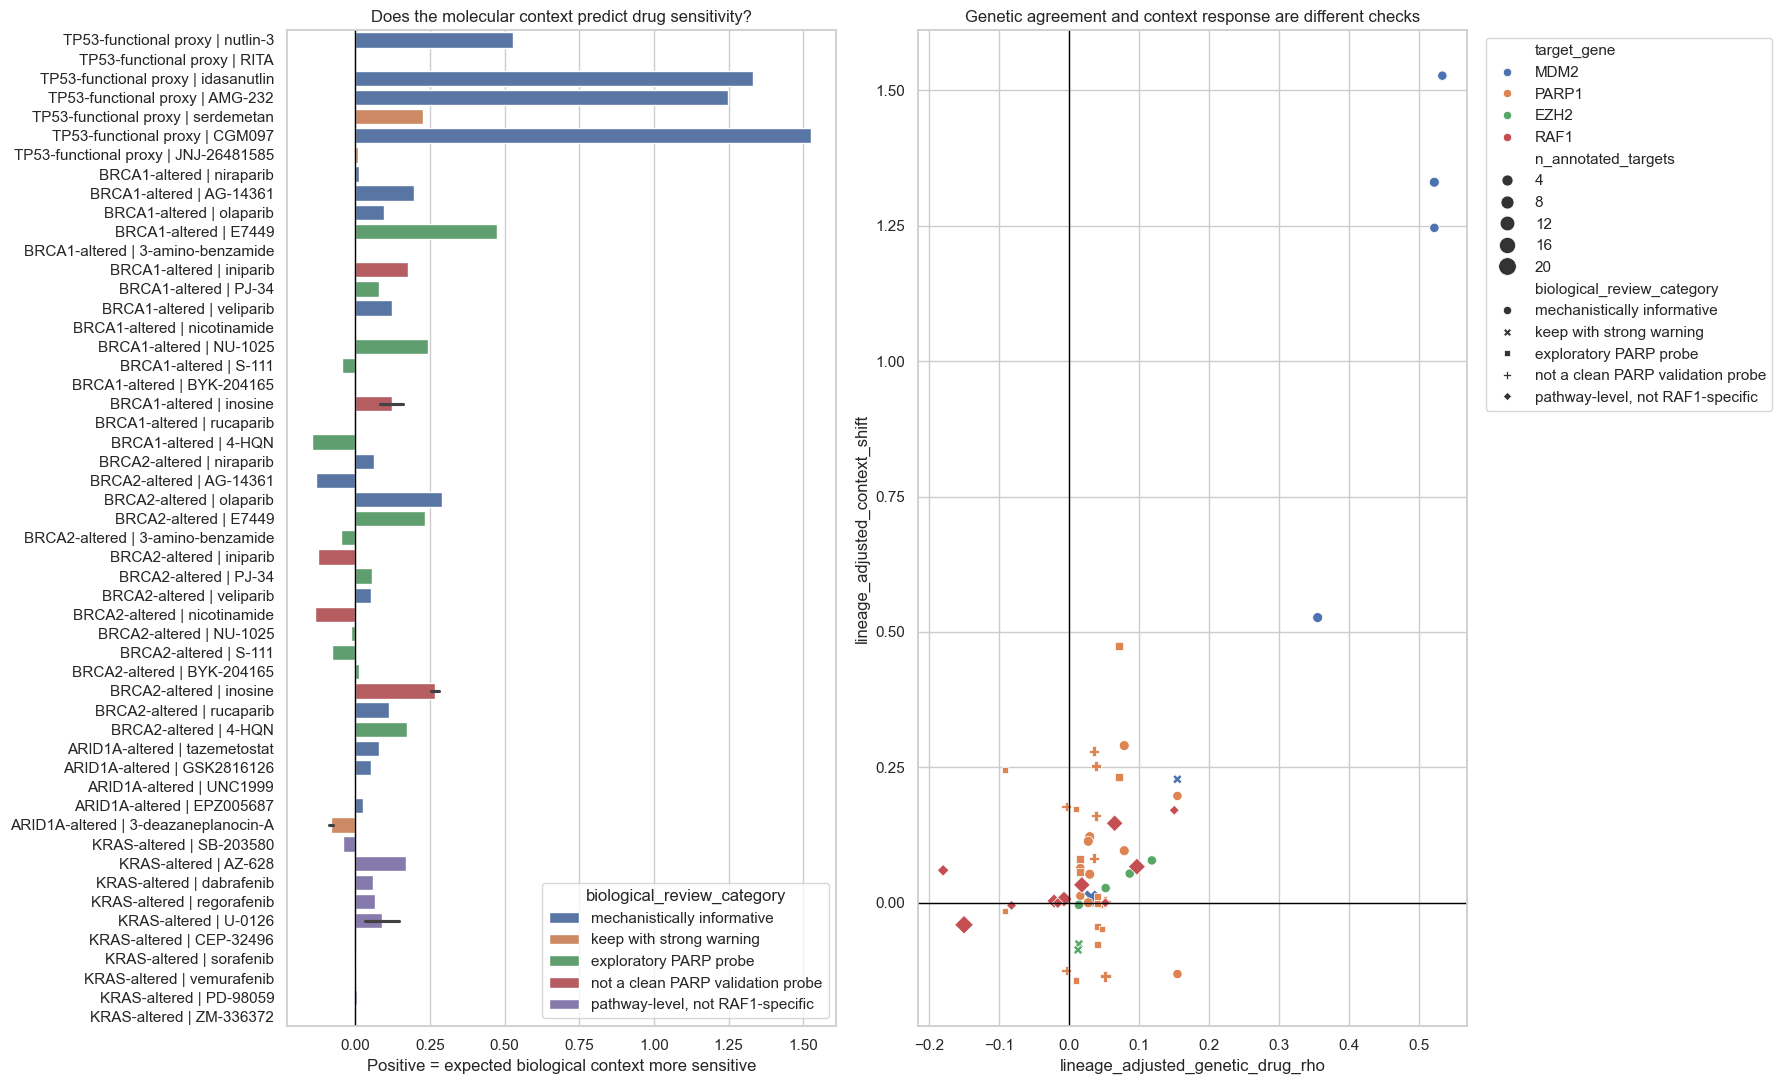

In [3]:
prism_response = pd.read_csv(PATHS['prism_response'], low_memory=False).rename(
    columns={'Unnamed: 0': 'model_id'}
).set_index('model_id')
master_ids = set(master['model_id'])
prism_model_ids = set(prism_response.index) & master_ids
crispr_model_ids = set(master.loc[master['has_crispr_gene_effect'].eq(1), 'model_id'])
shared_crispr_prism_ids = prism_model_ids & crispr_model_ids

target_long_rows = []
for row in prism_treatments.itertuples(index=False):
    targets = [] if pd.isna(row.target) else [x.strip().upper() for x in str(row.target).split(',') if x.strip()]
    for target in targets:
        target_long_rows.append({
            'treatment_id': row.column_name, 'drug_name': row.name, 'dose': row.dose,
            'screen_id': row.screen_id, 'moa': row.moa, 'target_gene': target,
            'annotated_targets': row.target, 'n_annotated_targets': len(targets),
        })
target_long = pd.DataFrame(target_long_rows)
review_targets = ['MDM2', 'PARP1', 'EZH2', 'RAF1']
review_treatments = target_long.loc[target_long['target_gene'].isin(review_targets)].copy()

effect_columns = gene_lookup.loc[review_targets, 'crispr_effect_column'].dropna().to_dict()
effect = pd.read_csv(PATHS['effect'], usecols=['Unnamed: 0', *effect_columns.values()]).rename(
    columns={'Unnamed: 0': 'model_id', **{v: k for k, v in effect_columns.items()}}
).set_index('model_id')

depmap_mutations['damaging_or_driver'] = (
    depmap_mutations['has_likely_lof'].eq(1)
    | depmap_mutations['highest_vep_impact'].eq('HIGH')
    | depmap_mutations[['has_hotspot', 'has_oncogene_high_impact', 'has_tumor_suppressor_high_impact']].eq(1).any(axis=1)
)
mutation_universe = prism_model_ids & set(master.loc[master['has_mutation_assay'].eq(1), 'model_id'])


def lineage_adjusted_drug_correlation(target_gene: str, treatment_id: str) -> dict:
    ids = sorted(shared_crispr_prism_ids & set(effect.index))
    frame = pd.DataFrame({
        'gene_effect': effect.loc[ids, target_gene],
        'drug_response': prism_response.loc[ids, treatment_id],
        'lineage': lineage_lookup.reindex(ids),
    }).dropna()
    keep = frame.groupby('lineage')['gene_effect'].transform('size').ge(10)
    adjusted = frame.loc[keep].copy()
    adjusted[['gene_effect', 'drug_response']] = adjusted[['gene_effect', 'drug_response']] - adjusted.groupby('lineage')[['gene_effect', 'drug_response']].transform('median')
    return {
        'shared_models': len(frame),
        'lineage_adjusted_models': len(adjusted),
        'lineage_adjusted_genetic_drug_rho': adjusted['gene_effect'].corr(adjusted['drug_response'], method='spearman') if len(adjusted) >= 30 else np.nan,
    }


def lineage_adjusted_context_shift(treatment_id: str, context_ids: set, reference_ids: set) -> dict:
    context = sorted(context_ids & prism_model_ids)
    reference = sorted(reference_ids & prism_model_ids)
    selected = context + reference
    frame = pd.DataFrame({
        'drug_response': prism_response.loc[selected, treatment_id],
        'lineage': lineage_lookup.reindex(selected),
        'group': ['Context'] * len(context) + ['Reference'] * len(reference),
    }).dropna()
    keep = frame.groupby('lineage')['drug_response'].transform('size').ge(10)
    adjusted = frame.loc[keep].copy()
    adjusted['response_residual'] = adjusted['drug_response'] - adjusted.groupby('lineage')['drug_response'].transform('median')
    context_values = adjusted.loc[adjusted['group'].eq('Context'), 'response_residual']
    reference_values = adjusted.loc[adjusted['group'].eq('Reference'), 'response_residual']
    usable = len(context_values) >= 10 and len(reference_values) >= 10
    return {
        'context_models': len(context_values), 'reference_models': len(reference_values),
        'lineage_adjusted_context_shift': reference_values.median() - context_values.median() if usable else np.nan,
    }


def altered_ids(gene: str) -> set:
    return set(depmap_mutations.loc[
        depmap_mutations['hugo_symbol'].eq(gene) & depmap_mutations['damaging_or_driver'], 'model_id'
    ]) & mutation_universe


hypotheses = pd.DataFrame([
    {'hypothesis': 'TP53-functional proxy -> MDM2 inhibitor', 'context_gene': 'TP53', 'target_gene': 'MDM2', 'context_definition': 'mutation-assayed with no damaging/driver TP53 event', 'expected_direction': 'functional proxy more sensitive'},
    {'hypothesis': 'BRCA1-altered -> PARP1 inhibitor', 'context_gene': 'BRCA1', 'target_gene': 'PARP1', 'context_definition': 'damaging/driver BRCA1 event', 'expected_direction': 'altered more sensitive'},
    {'hypothesis': 'BRCA2-altered -> PARP1 inhibitor', 'context_gene': 'BRCA2', 'target_gene': 'PARP1', 'context_definition': 'damaging/driver BRCA2 event', 'expected_direction': 'altered more sensitive'},
    {'hypothesis': 'ARID1A-altered -> EZH2 inhibitor', 'context_gene': 'ARID1A', 'target_gene': 'EZH2', 'context_definition': 'damaging/driver ARID1A event', 'expected_direction': 'altered more sensitive'},
    {'hypothesis': 'KRAS-altered -> RAF1 inhibitor', 'context_gene': 'KRAS', 'target_gene': 'RAF1', 'context_definition': 'damaging/driver KRAS event', 'expected_direction': 'altered more sensitive'},
])


def review_category(target: str, drug: str, n_targets: int) -> tuple[str, str]:
    name = str(drug).lower()
    if target == 'MDM2':
        if name in {'nutlin-3', 'idasanutlin', 'amg-232', 'cgm097'}:
            return 'mechanistically informative', 'direct MDM2-p53 antagonist; interpret with TP53 context'
        return 'keep with strong warning', 'less direct or highly multi-target MDM2 annotation'
    if target == 'PARP1':
        if name in {'olaparib', 'niraparib', 'rucaparib', 'veliparib', 'ag-14361'}:
            return 'mechanistically informative', 'recognisable PARP inhibitor; exact dose and target count still matter'
        if name in {'iniparib', 'nicotinamide', 'inosine'}:
            return 'not a clean PARP validation probe', 'annotation does not provide specific PARP1 perturbation'
        return 'exploratory PARP probe', 'PARP-directed annotation with weaker clinical or selectivity interpretation'
    if target == 'EZH2':
        if name in {'tazemetostat', 'gsk2816126', 'unc1999', 'epz005687'}:
            return 'mechanistically informative', 'direct EZH2 inhibitor; screen duration remains a limitation'
        return 'keep with strong warning', 'indirect or broad epigenetic compound'
    return 'pathway-level, not RAF1-specific', 'compound targets multiple RAF/MAPK or unrelated proteins'


review_rows = []
for hypothesis in hypotheses.itertuples(index=False):
    altered = altered_ids(hypothesis.context_gene)
    if hypothesis.context_gene == 'TP53':
        context_ids, reference_ids = mutation_universe - altered, altered
    else:
        context_ids, reference_ids = altered, mutation_universe - altered
    treatments = review_treatments.loc[review_treatments['target_gene'].eq(hypothesis.target_gene)]
    for treatment in treatments.itertuples(index=False):
        category, reason = review_category(treatment.target_gene, treatment.drug_name, treatment.n_annotated_targets)
        review_rows.append({
            'hypothesis': hypothesis.hypothesis,
            'context_definition': hypothesis.context_definition,
            'expected_direction': hypothesis.expected_direction,
            'target_gene': treatment.target_gene,
            'drug_name': treatment.drug_name,
            'dose': treatment.dose,
            'treatment_id': treatment.treatment_id,
            'moa': treatment.moa,
            'annotated_targets': treatment.annotated_targets,
            'n_annotated_targets': treatment.n_annotated_targets,
            'biological_review_category': category,
            'biological_reason': reason,
            **lineage_adjusted_drug_correlation(treatment.target_gene, treatment.treatment_id),
            **lineage_adjusted_context_shift(treatment.treatment_id, context_ids, reference_ids),
        })
drug_biological_review = pd.DataFrame(review_rows)
drug_biological_review['observed_direction'] = np.select(
    [drug_biological_review['lineage_adjusted_context_shift'].gt(0), drug_biological_review['lineage_adjusted_context_shift'].lt(0)],
    ['supports expected sensitivity direction', 'opposes expected sensitivity direction'],
    default='not evaluable or tied',
)

review_summary = drug_biological_review.groupby(['hypothesis', 'biological_review_category'], dropna=False).agg(
    treatment_conditions=('treatment_id', 'nunique'),
    evaluable_context_shifts=('lineage_adjusted_context_shift', 'count'),
    positive_context_shifts=('lineage_adjusted_context_shift', lambda s: int(s.gt(0).sum())),
    median_context_shift=('lineage_adjusted_context_shift', 'median'),
    median_genetic_drug_rho=('lineage_adjusted_genetic_drug_rho', 'median'),
).reset_index()
display(review_summary)
display(drug_biological_review.sort_values(
    ['hypothesis', 'biological_review_category', 'lineage_adjusted_context_shift'],
    ascending=[True, True, False]
))

plot_drugs = drug_biological_review.loc[drug_biological_review['lineage_adjusted_context_shift'].notna()].copy()
plot_drugs['label'] = plot_drugs['hypothesis'].str.split(' ->').str[0] + ' | ' + plot_drugs['drug_name'].astype(str)
fig, axes = plt.subplots(1, 2, figsize=(18, 11))
sns.barplot(data=plot_drugs, x='lineage_adjusted_context_shift', y='label', hue='biological_review_category', dodge=False, ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Does the molecular context predict drug sensitivity?')
axes[0].set_xlabel('Positive = expected biological context more sensitive'); axes[0].set_ylabel('')
sns.scatterplot(data=drug_biological_review, x='lineage_adjusted_genetic_drug_rho', y='lineage_adjusted_context_shift',
                hue='target_gene', style='biological_review_category', size='n_annotated_targets', sizes=(45, 180), ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1); axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Genetic agreement and context response are different checks')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()


### What this means for the project

Drug response should not be reduced to “the target name appears in the metadata.” The MDM2 examples are meaningful only when TP53 is likely functional. The BRCA-PARP examples have strong biological backing, but individual PARP-labelled compounds differ greatly in specificity. Selective EZH2 compounds are more interpretable than broad epigenetic agents, while the RAF1 list mainly tests the wider RAF/MAPK pathway rather than RAF1 alone. Therefore, exact treatment-level results can support an explanation, but neither the treatment count nor an average across all annotated drugs should become a training label.

The TP53 “functional” group is only a proxy based on no recorded damaging/driver mutation in mutation-assayed models. It does not measure every way p53 signalling can be disabled. Likewise, a single PRISM dose and short viability assay cannot perfectly reproduce a gene knockout or longer epigenetic treatment.


## 3. Exact structural-variant recurrence in tumours

This is the closest TCGA layer to direct fusion evidence. Both gene endpoints must match the exact canonical pair. The denominator is the number of primary tumour samples measured for structural variants in the relevant study.


,pair_id,expected_study_id,disease_context,sv_positive_samples,sv_event_rows,measured_primary_samples,tumour_prevalence_pct,validation_state
0,ABL1--BCR,laml_tcga_pan_can_atlas_2018,acute myeloid leukaemia,4,4,200,2.000000,observed exact pair
1,ALK--EML4,luad_tcga_pan_can_atlas_2018,lung adenocarcinoma,5,5,510,0.980392,observed exact pair
2,ERG--TMPRSS2,prad_tcga_pan_can_atlas_2018,prostate adenocarcinoma,189,194,494,38.259109,observed exact pair
3,EWSR1--FLI1,sarc_tcga_pan_can_atlas_2018,sarcoma cohort,0,0,255,0.000000,no exact event in this cohort/release


,exact_sv_pair,study_id,event_rows,positive_samples
5,ERG--TMPRSS2,prad_tcga_pan_can_atlas_2018,194,189
2,ALK--EML4,luad_tcga_pan_can_atlas_2018,5,5
0,ABL1--BCR,laml_tcga_pan_can_atlas_2018,4,4
1,ALK--EML4,kirp_tcga_pan_can_atlas_2018,1,1
3,ALK--EML4,thca_tcga_pan_can_atlas_2018,1,1
4,ERG--TMPRSS2,pcpg_tcga_pan_can_atlas_2018,1,1


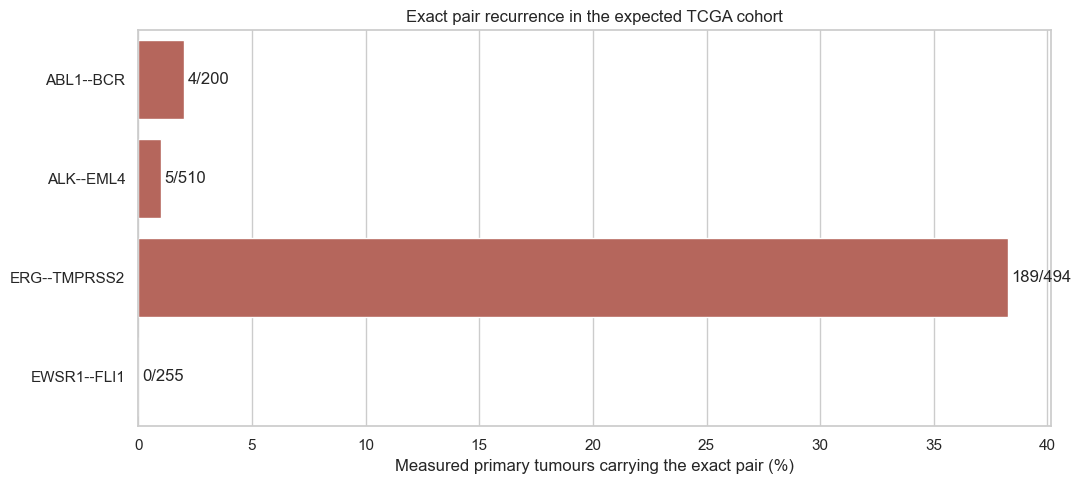

In [4]:
tcga_sv_work = tcga_sv.rename(columns={
    'studyId': 'study_id', 'sampleId': 'sample_id', 'patientId': 'patient_id',
    'site1HugoSymbol': 'gene_a', 'site2HugoSymbol': 'gene_b',
}).copy()
tcga_sv_work['exact_sv_pair'] = [
    canonical_pair(a, b) if pd.notna(a) and pd.notna(b) else pd.NA
    for a, b in tcga_sv_work[['gene_a', 'gene_b']].itertuples(index=False, name=None)
]
primary_key = set(zip(primary_samples['study_id'], primary_samples['sample_id']))
tcga_sv_primary = tcga_sv_work.loc[
    [(study, sample) in primary_key for study, sample in tcga_sv_work[['study_id', 'sample_id']].itertuples(index=False, name=None)]
].copy()

fusion_cohorts = pd.DataFrame([
    {'pair_id': canonical_pair('BCR', 'ABL1'), 'expected_study_id': 'laml_tcga_pan_can_atlas_2018', 'disease_context': 'acute myeloid leukaemia'},
    {'pair_id': canonical_pair('EML4', 'ALK'), 'expected_study_id': 'luad_tcga_pan_can_atlas_2018', 'disease_context': 'lung adenocarcinoma'},
    {'pair_id': canonical_pair('TMPRSS2', 'ERG'), 'expected_study_id': 'prad_tcga_pan_can_atlas_2018', 'disease_context': 'prostate adenocarcinoma'},
    {'pair_id': canonical_pair('EWSR1', 'FLI1'), 'expected_study_id': 'sarc_tcga_pan_can_atlas_2018', 'disease_context': 'sarcoma cohort'},
])

fusion_validation_rows = []
for row in fusion_cohorts.itertuples(index=False):
    measured = measured_sets[(row.expected_study_id, 'structural_variant')]
    events = tcga_sv_primary.loc[
        tcga_sv_primary['study_id'].eq(row.expected_study_id)
        & tcga_sv_primary['exact_sv_pair'].eq(row.pair_id)
        & tcga_sv_primary['sample_id'].isin(measured)
    ]
    positive = events['sample_id'].nunique()
    fusion_validation_rows.append({
        **row._asdict(),
        'sv_positive_samples': positive,
        'sv_event_rows': len(events),
        'measured_primary_samples': len(measured),
        'tumour_prevalence_pct': 100 * positive / len(measured) if measured else np.nan,
        'validation_state': 'observed exact pair' if positive else 'no exact event in this cohort/release',
    })
fusion_validation = pd.DataFrame(fusion_validation_rows)

event_bearing_pairs = tcga_sv_primary.loc[tcga_sv_primary['exact_sv_pair'].isin(fusion_cohorts['pair_id'])].groupby(
    ['exact_sv_pair', 'study_id'], as_index=False
).agg(event_rows=('sample_id', 'size'), positive_samples=('sample_id', 'nunique'))
display(fusion_validation)
display(event_bearing_pairs.sort_values(['positive_samples', 'event_rows'], ascending=False))

plt.figure(figsize=(11, 5))
sns.barplot(data=fusion_validation, x='tumour_prevalence_pct', y='pair_id', color='#c45b4d')
for index, row in fusion_validation.reset_index(drop=True).iterrows():
    plt.text(row.tumour_prevalence_pct + 0.15, index,
             f"{row.sv_positive_samples}/{row.measured_primary_samples}", va='center')
plt.title('Exact pair recurrence in the expected TCGA cohort')
plt.xlabel('Measured primary tumours carrying the exact pair (%)'); plt.ylabel('')
plt.tight_layout(); plt.show()

assert fusion_validation['sv_positive_samples'].le(fusion_validation['measured_primary_samples']).all()


### What this means for the project

The tumour data reproduce several biologically recognisable direct pairs: `ERG--TMPRSS2` is recurrent in the prostate cohort, while `ALK--EML4` and `ABL1--BCR` appear in smaller expected cohorts. `EWSR1--FLI1` is not observed in the selected TCGA sarcoma data. That absence means “not found by this study, assay, panel pull, and release,” not “the fusion does not exist.” TCGA structural-variant recurrence is therefore strong external evidence when present, but it cannot be the universal answer key because coverage and cancer composition vary.


## 4. Tumour mutation and copy-number context

For tumour mutations, this notebook keeps two visible definitions. `Any protein-altering` includes missense and in-frame changes as well as disruptive events. `Truncating or splice` is a narrower loss-of-function proxy. Missense mutations are not automatically called damaging because hotspot/driver annotation was not acquired in this panel pull.

For copy number, TCGA uses GISTIC categories. `MTAP <= -1` is any loss and `MTAP == -2` is deep deletion. These are not directly interchangeable with DepMap absolute copy-number thresholds.


,study_id,gene_symbol,measured_primary_samples,any_protein_altering_samples,any_protein_altering_pct,truncating_or_splice_samples,truncating_or_splice_pct
104,paad_tcga_pan_can_atlas_2018,KRAS,179,117,65.363128,0,0.000000
145,ucec_tcga_pan_can_atlas_2018,ARID1A,517,227,43.907157,207,40.038685
29,coadread_tcga_pan_can_atlas_2018,KRAS,534,218,40.823970,1,0.187266
84,luad_tcga_pan_can_atlas_2018,KRAS,566,168,29.681979,1,0.176678
5,blca_tcga_pan_can_atlas_2018,ARID1A,410,105,25.609756,86,20.975610
125,stad_tcga_pan_can_atlas_2018,ARID1A,436,110,25.229358,97,22.247706
149,ucec_tcga_pan_can_atlas_2018,KRAS,517,99,19.148936,1,0.193424
148,ucec_tcga_pan_can_atlas_2018,BRCA2,517,80,15.473888,33,6.382979
150,ucs_tcga_pan_can_atlas_2018,ARID1A,57,7,12.280702,5,8.771930
154,ucs_tcga_pan_can_atlas_2018,KRAS,57,7,12.280702,0,0.000000


,study_id,measured_primary_samples,any_loss_samples,deep_deletion_samples,any_loss_pct,deep_deletion_pct
17,lusc_tcga_pan_can_atlas_2018,487,370,95,75.975359,19.507187
8,gbm_tcga_pan_can_atlas_2018,575,425,244,73.913043,42.434783
7,esca_tcga_pan_can_atlas_2018,182,124,38,68.131868,20.879121
29,ucs_tcga_pan_can_atlas_2018,56,33,1,58.928571,1.785714
20,paad_tcga_pan_can_atlas_2018,183,107,40,58.469945,21.857923
4,chol_tcga_pan_can_atlas_2018,36,21,4,58.333333,11.111111
1,blca_tcga_pan_can_atlas_2018,408,231,106,56.617647,25.980392
16,luad_tcga_pan_can_atlas_2018,511,289,62,56.555773,12.133072
18,meso_tcga_pan_can_atlas_2018,87,48,28,55.172414,32.183908
9,hnsc_tcga_pan_can_atlas_2018,517,257,75,49.709865,14.506770


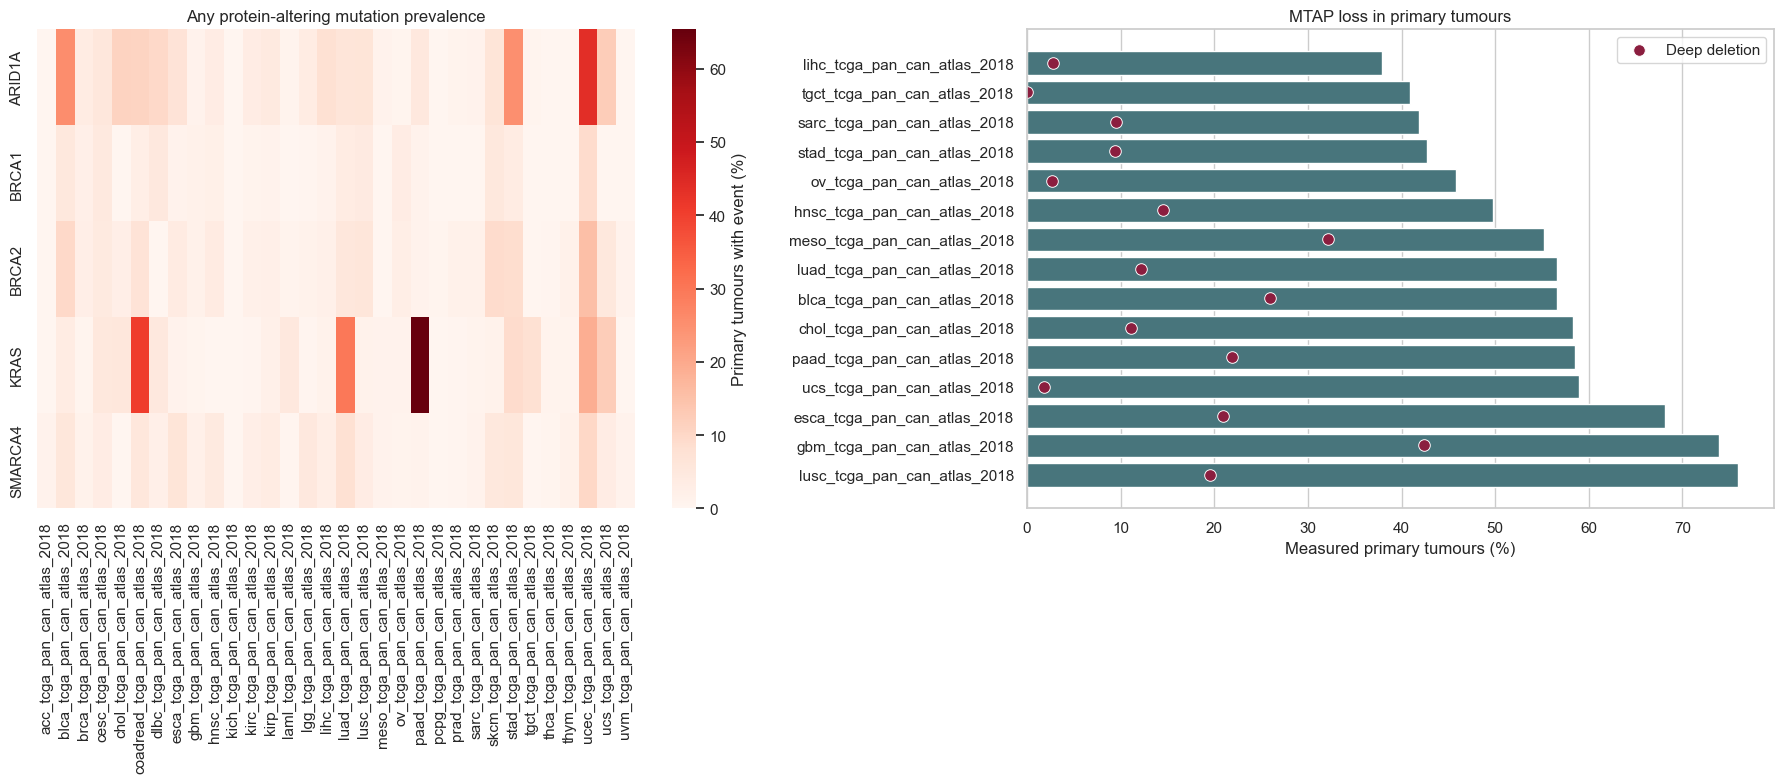

In [5]:
tcga_mut_work = tcga_mutations.rename(columns={
    'studyId': 'study_id', 'sampleId': 'sample_id', 'patientId': 'patient_id',
    'geneSymbol': 'gene_symbol', 'mutationType': 'mutation_type',
}).copy()
tcga_mut_work['any_protein_altering'] = True
truncating_types = {
    'Nonsense_Mutation', 'Frame_Shift_Del', 'Frame_Shift_Ins', 'Splice_Site',
    'Translation_Start_Site', 'Nonstop_Mutation',
}
tcga_mut_work['truncating_or_splice'] = tcga_mut_work['mutation_type'].isin(truncating_types)

mutation_context_genes = ['ARID1A', 'SMARCA4', 'BRCA1', 'BRCA2', 'KRAS']
mutation_prevalence_rows = []
for study_id in tcga_studies['study_id']:
    measured = measured_sets[(study_id, 'mutation')]
    for gene in mutation_context_genes:
        events = tcga_mut_work.loc[
            tcga_mut_work['study_id'].eq(study_id)
            & tcga_mut_work['gene_symbol'].eq(gene)
            & tcga_mut_work['sample_id'].isin(measured)
        ]
        any_positive = events['sample_id'].nunique()
        trunc_positive = events.loc[events['truncating_or_splice'], 'sample_id'].nunique()
        mutation_prevalence_rows.append({
            'study_id': study_id, 'gene_symbol': gene,
            'measured_primary_samples': len(measured),
            'any_protein_altering_samples': any_positive,
            'any_protein_altering_pct': 100 * any_positive / len(measured) if measured else np.nan,
            'truncating_or_splice_samples': trunc_positive,
            'truncating_or_splice_pct': 100 * trunc_positive / len(measured) if measured else np.nan,
        })
mutation_prevalence = pd.DataFrame(mutation_prevalence_rows)
mutation_display = mutation_prevalence.loc[mutation_prevalence['measured_primary_samples'].ge(30)].copy()
display(mutation_display.sort_values('any_protein_altering_pct', ascending=False).head(25))

primary_sample_keys = primary_samples[['study_id', 'sample_id']].drop_duplicates()
tcga_cna_primary = tcga_cna.merge(primary_sample_keys, on=['study_id', 'sample_id'], how='inner', validate='many_to_one')
mtap_cna = tcga_cna_primary.loc[tcga_cna_primary['gene_symbol'].eq('MTAP')].copy()
cna_prevalence = mtap_cna.groupby('study_id', as_index=False).agg(
    measured_primary_samples=('sample_id', 'nunique'),
    any_loss_samples=('value', lambda s: int(s.le(-1).sum())),
    deep_deletion_samples=('value', lambda s: int(s.eq(-2).sum())),
)
cna_prevalence['any_loss_pct'] = 100 * cna_prevalence['any_loss_samples'] / cna_prevalence['measured_primary_samples']
cna_prevalence['deep_deletion_pct'] = 100 * cna_prevalence['deep_deletion_samples'] / cna_prevalence['measured_primary_samples']
display(cna_prevalence.sort_values('any_loss_pct', ascending=False).head(20))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
mutation_heatmap = mutation_display.pivot(index='gene_symbol', columns='study_id', values='any_protein_altering_pct')
sns.heatmap(mutation_heatmap, cmap='Reds', vmin=0, cbar_kws={'label': 'Primary tumours with event (%)'}, ax=axes[0])
axes[0].set_title('Any protein-altering mutation prevalence'); axes[0].set_xlabel(''); axes[0].set_ylabel('')
plot_cna = cna_prevalence.nlargest(15, 'any_loss_pct').sort_values('any_loss_pct')
sns.barplot(data=plot_cna, x='any_loss_pct', y='study_id', color='#3f7c85', ax=axes[1])
sns.scatterplot(data=plot_cna, x='deep_deletion_pct', y='study_id', color='#8b1e3f', s=70, ax=axes[1], label='Deep deletion')
axes[1].set_title('MTAP loss in primary tumours'); axes[1].set_xlabel('Measured primary tumours (%)'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

assert mutation_prevalence['any_protein_altering_samples'].le(mutation_prevalence['measured_primary_samples']).all()
assert mutation_prevalence['truncating_or_splice_samples'].le(mutation_prevalence['any_protein_altering_samples']).all()
assert cna_prevalence['deep_deletion_samples'].le(cna_prevalence['any_loss_samples']).all()


### What this means for the project

TCGA can show whether a proposed molecular context occurs in real tumours and in which cancer cohorts it is common. It cannot by itself show that the partner gene is a dependency. For example, an MTAP deletion in a tumour makes the `MTAP -> PRMT5` or `MTAP -> MAT2A` hypothesis biologically relevant, but CRISPR or drug evidence is still needed to show vulnerability. Keeping broad mutation events separate from truncating/splice events avoids claiming that every missense change destroys the gene.


## 5. Within-study tumour RNA relationships

Raw RSEM values are not pooled across cancer studies. For each study, expression is clipped at zero only to handle a small number of tiny negative processed values, transformed with `log2(value + 1)`, and compared with Spearman correlation. Correlation is calculated only when at least 30 primary tumours have both genes measured.


,pair_id,evaluable_studies,median_within_study_rho,minimum_within_study_rho,maximum_within_study_rho,positive_rho_studies,median_pair_samples,positive_rho_study_pct
4,BRCA1--BRCA2,32,0.644422,0.327490,0.795187,32,268.0,100.00000
10,KEAP1--STK11,32,0.362146,0.004044,0.757646,32,268.0,100.00000
5,BRCA1--PARP1,32,0.347965,0.075228,0.741701,32,268.0,100.00000
6,BRCA2--PARP1,32,0.340032,-0.084564,0.506823,31,268.0,96.87500
3,BRAF--MAPK1,32,0.334746,0.093777,0.645028,32,268.0,100.00000
13,MTAP--PRMT5,32,0.146599,-0.094293,0.350579,26,268.0,81.25000
12,MAT2A--MTAP,32,0.105757,-0.264667,0.514651,24,268.0,75.00000
2,ARID1A--EZH2,32,0.092937,-0.184647,0.400024,25,268.0,78.12500
0,ABL1--BCR,32,0.091800,-0.447643,0.544637,27,268.0,84.37500
11,KRAS--RAF1,32,0.062742,-0.241790,0.494898,23,268.0,71.87500


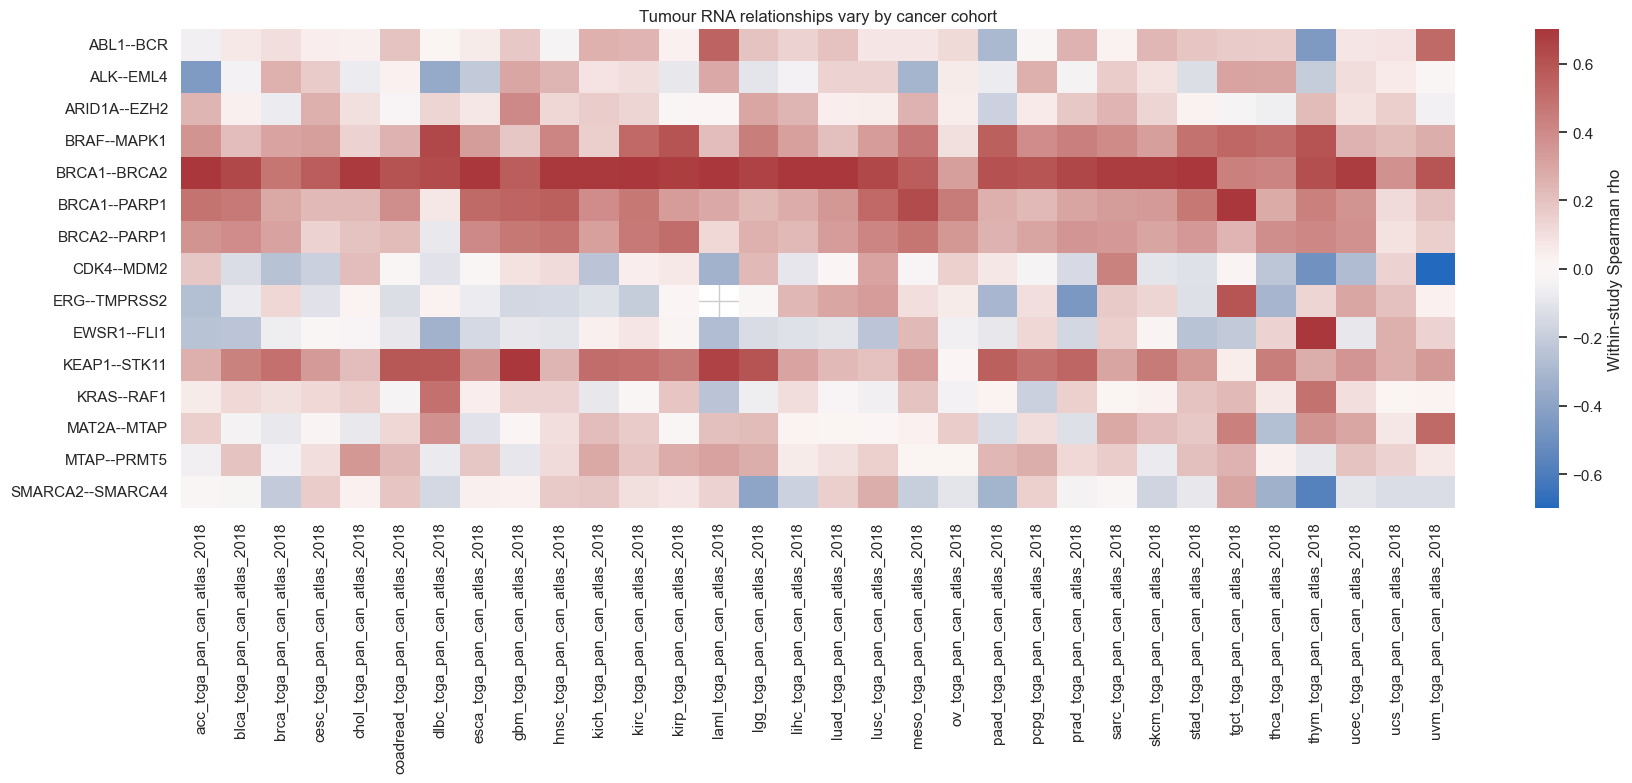

In [6]:
pair_specs = [
    ('BCR', 'ABL1'), ('EML4', 'ALK'), ('TMPRSS2', 'ERG'), ('EWSR1', 'FLI1'),
    ('ARID1A', 'EZH2'), ('SMARCA4', 'SMARCA2'), ('BRCA1', 'PARP1'),
    ('BRCA2', 'PARP1'), ('KRAS', 'RAF1'), ('MTAP', 'PRMT5'), ('MTAP', 'MAT2A'),
    ('BRCA1', 'BRCA2'), ('CDK4', 'MDM2'), ('BRAF', 'MAPK1'), ('STK11', 'KEAP1'),
]
pair_catalog = pd.DataFrame(pair_specs, columns=['input_gene_a', 'input_gene_b'])
pair_catalog['pair_id'] = [canonical_pair(a, b) for a, b in pair_specs]
pair_catalog[['gene_a', 'gene_b']] = pair_catalog['pair_id'].str.split('--', expand=True)

tcga_rna_primary = tcga_rna.merge(primary_sample_keys, on=['study_id', 'sample_id'], how='inner', validate='many_to_one')
tcga_rna_primary['log2_rsem'] = np.log2(tcga_rna_primary['value'].clip(lower=0) + 1)
rna_pair_rows = []
for study_id, study_data in tcga_rna_primary.groupby('study_id'):
    matrix = study_data.pivot(index='sample_id', columns='gene_symbol', values='log2_rsem')
    for pair in pair_catalog.itertuples(index=False):
        if pair.gene_a not in matrix.columns or pair.gene_b not in matrix.columns:
            continue
        both = matrix[[pair.gene_a, pair.gene_b]].dropna()
        rho = both[pair.gene_a].corr(both[pair.gene_b], method='spearman') if len(both) >= 30 else np.nan
        rna_pair_rows.append({
            'study_id': study_id, 'pair_id': pair.pair_id,
            'rna_pair_samples': len(both), 'within_study_rna_rho': rho,
        })
rna_pair = pd.DataFrame(rna_pair_rows)
rna_summary = rna_pair.groupby('pair_id', as_index=False).agg(
    evaluable_studies=('within_study_rna_rho', 'count'),
    median_within_study_rho=('within_study_rna_rho', 'median'),
    minimum_within_study_rho=('within_study_rna_rho', 'min'),
    maximum_within_study_rho=('within_study_rna_rho', 'max'),
    positive_rho_studies=('within_study_rna_rho', lambda s: int(s.gt(0).sum())),
    median_pair_samples=('rna_pair_samples', 'median'),
)
rna_summary['positive_rho_study_pct'] = 100 * rna_summary['positive_rho_studies'] / rna_summary['evaluable_studies']
display(rna_summary.sort_values('median_within_study_rho', ascending=False))

rna_heatmap = rna_pair.pivot(index='pair_id', columns='study_id', values='within_study_rna_rho')
plt.figure(figsize=(18, 8))
sns.heatmap(rna_heatmap, cmap='vlag', center=0, vmin=-0.7, vmax=0.7, cbar_kws={'label': 'Within-study Spearman rho'})
plt.title('Tumour RNA relationships vary by cancer cohort')
plt.xlabel(''); plt.ylabel('')
plt.tight_layout(); plt.show()

assert rna_pair.loc[rna_pair['within_study_rna_rho'].notna(), 'rna_pair_samples'].ge(30).all()


### What this means for the project

RNA correlation asks whether two genes rise and fall together across tumours in the same cancer cohort. This can support a shared pathway, common regulation, cell-type mixture, or copy-number effect, but it does not prove fusion, physical binding, or synthetic lethality. A relationship that changes direction between cohorts is especially important: it suggests that disease context must remain visible instead of using one pooled pan-cancer correlation.


## 6. Cross-source feature audit

The table below is the design contract for future feature engineering. It separates measured biological routes from confidence metadata, external validation, biological explanation, and unsafe shortcuts.


,candidate_features
audit_status,
external_validation_only,7
do_not_use,4
keep,3
keep_with_warning,2
coverage_only,1
explanation_only,1


,candidate_feature,route_family,biological_question,grain,denominator,transform,missing_state,leakage_risk,audit_status
0,direct_fusion_model_prevalence,direct fusion,Is the exact gene pair observed as a fusion in...,pair x eligible cell-line cohort,fusion-assayed models in the cohort,positive models / measured models,"not measured or no event, kept distinct",high if fusion pairs are also used as the answ...,keep
1,fusion_read_and_breakpoint_support,direct fusion QC,How technically credible is a fusion call?,fusion event,not applicable,retain source fields; no silent averaging,support field unavailable,low,keep_with_warning
2,lineage_adjusted_crispr_codependency_rho,codependency,Do the two knockouts affect viability similarl...,pair x eligible cell-line cohort,models with both CRISPR measurements,within-lineage residual Spearman rho,insufficient shared models,medium if CRISPR later defines the label,keep
3,conditional_crispr_effect_shift,conditional dependency,Does altering Gene A increase dependency on Ge...,directional pair x molecular context x cohort,context and reference models with required assays,lineage-adjusted median shift with group sizes,context not measured or groups too small,medium if the same CRISPR value defines outcome,keep
4,leave_one_lineage_out_route_stability,stability/QC,Does one lineage dominate the route?,pair x route x held-out lineage,eligible models after each holdout,direction agreement and effect range,too few lineages,low when calculated only in training data,keep_with_warning
5,prism_genetic_drug_rho,drug corroboration,Does chemical response resemble loss of the an...,target x exact treatment,models with both PRISM and CRISPR,lineage-adjusted Spearman rho,target/treatment or overlap unavailable,high if later drug response is an outcome,external_validation_only
6,prism_context_drug_shift,drug corroboration,Is the molecular context more sensitive to a t...,directional pair x exact treatment,context and reference PRISM models,lineage-adjusted median sensitivity shift,not screened or groups too small,high if drug response defines the label,external_validation_only
7,targeted_treatment_count,drug coverage,How many annotated chemical conditions were av...,target gene,PRISM treatment catalogue,count only,no annotation,encodes research popularity and druggability bias,coverage_only
8,tcga_exact_sv_recurrence,tumour direct fusion,Does the exact pair recur in primary tumours?,pair x TCGA study,SV-measured primary tumours,positive samples / measured samples,study/layer unmeasured kept separate from zero...,high if TCGA fusion recurrence becomes the ans...,external_validation_only
9,tcga_any_protein_altering_prevalence,tumour mutation context,How often is the context gene altered in a tum...,gene x TCGA study,mutation-measured primary tumours,event-positive samples / measured samples,assay unmeasured,"low, but it measures context frequency rather ...",external_validation_only


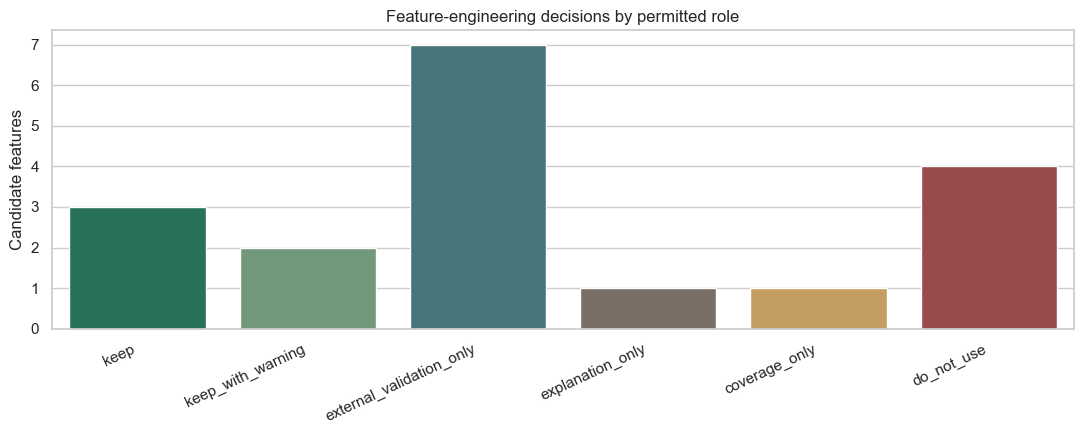

In [7]:
feature_audit = pd.DataFrame([
    {'candidate_feature': 'direct_fusion_model_prevalence', 'route_family': 'direct fusion', 'biological_question': 'Is the exact gene pair observed as a fusion in cell lines?', 'grain': 'pair x eligible cell-line cohort', 'denominator': 'fusion-assayed models in the cohort', 'transform': 'positive models / measured models', 'missing_state': 'not measured or no event, kept distinct', 'leakage_risk': 'high if fusion pairs are also used as the answer key', 'audit_status': 'keep'},
    {'candidate_feature': 'fusion_read_and_breakpoint_support', 'route_family': 'direct fusion QC', 'biological_question': 'How technically credible is a fusion call?', 'grain': 'fusion event', 'denominator': 'not applicable', 'transform': 'retain source fields; no silent averaging', 'missing_state': 'support field unavailable', 'leakage_risk': 'low', 'audit_status': 'keep_with_warning'},
    {'candidate_feature': 'lineage_adjusted_crispr_codependency_rho', 'route_family': 'codependency', 'biological_question': 'Do the two knockouts affect viability similarly across models?', 'grain': 'pair x eligible cell-line cohort', 'denominator': 'models with both CRISPR measurements', 'transform': 'within-lineage residual Spearman rho', 'missing_state': 'insufficient shared models', 'leakage_risk': 'medium if CRISPR later defines the label', 'audit_status': 'keep'},
    {'candidate_feature': 'conditional_crispr_effect_shift', 'route_family': 'conditional dependency', 'biological_question': 'Does altering Gene A increase dependency on Gene B?', 'grain': 'directional pair x molecular context x cohort', 'denominator': 'context and reference models with required assays', 'transform': 'lineage-adjusted median shift with group sizes', 'missing_state': 'context not measured or groups too small', 'leakage_risk': 'medium if the same CRISPR value defines outcome', 'audit_status': 'keep'},
    {'candidate_feature': 'leave_one_lineage_out_route_stability', 'route_family': 'stability/QC', 'biological_question': 'Does one lineage dominate the route?', 'grain': 'pair x route x held-out lineage', 'denominator': 'eligible models after each holdout', 'transform': 'direction agreement and effect range', 'missing_state': 'too few lineages', 'leakage_risk': 'low when calculated only in training data', 'audit_status': 'keep_with_warning'},
    {'candidate_feature': 'prism_genetic_drug_rho', 'route_family': 'drug corroboration', 'biological_question': 'Does chemical response resemble loss of the annotated target?', 'grain': 'target x exact treatment', 'denominator': 'models with both PRISM and CRISPR', 'transform': 'lineage-adjusted Spearman rho', 'missing_state': 'target/treatment or overlap unavailable', 'leakage_risk': 'high if later drug response is an outcome', 'audit_status': 'external_validation_only'},
    {'candidate_feature': 'prism_context_drug_shift', 'route_family': 'drug corroboration', 'biological_question': 'Is the molecular context more sensitive to a target-directed treatment?', 'grain': 'directional pair x exact treatment', 'denominator': 'context and reference PRISM models', 'transform': 'lineage-adjusted median sensitivity shift', 'missing_state': 'not screened or groups too small', 'leakage_risk': 'high if drug response defines the label', 'audit_status': 'external_validation_only'},
    {'candidate_feature': 'targeted_treatment_count', 'route_family': 'drug coverage', 'biological_question': 'How many annotated chemical conditions were available?', 'grain': 'target gene', 'denominator': 'PRISM treatment catalogue', 'transform': 'count only', 'missing_state': 'no annotation', 'leakage_risk': 'encodes research popularity and druggability bias', 'audit_status': 'coverage_only'},
    {'candidate_feature': 'tcga_exact_sv_recurrence', 'route_family': 'tumour direct fusion', 'biological_question': 'Does the exact pair recur in primary tumours?', 'grain': 'pair x TCGA study', 'denominator': 'SV-measured primary tumours', 'transform': 'positive samples / measured samples', 'missing_state': 'study/layer unmeasured kept separate from zero events', 'leakage_risk': 'high if TCGA fusion recurrence becomes the answer key', 'audit_status': 'external_validation_only'},
    {'candidate_feature': 'tcga_any_protein_altering_prevalence', 'route_family': 'tumour mutation context', 'biological_question': 'How often is the context gene altered in a tumour cohort?', 'grain': 'gene x TCGA study', 'denominator': 'mutation-measured primary tumours', 'transform': 'event-positive samples / measured samples', 'missing_state': 'assay unmeasured', 'leakage_risk': 'low, but it measures context frequency rather than pair validity', 'audit_status': 'external_validation_only'},
    {'candidate_feature': 'tcga_truncating_splice_prevalence', 'route_family': 'tumour mutation context', 'biological_question': 'How often does the context gene have a likely disruptive event?', 'grain': 'gene x TCGA study', 'denominator': 'mutation-measured primary tumours', 'transform': 'truncating/splice-positive samples / measured samples', 'missing_state': 'assay unmeasured', 'leakage_risk': 'low, but hotspot missense biology is omitted', 'audit_status': 'external_validation_only'},
    {'candidate_feature': 'tcga_gistic_loss_prevalence', 'route_family': 'tumour CNA context', 'biological_question': 'How often is the context gene lost in tumours?', 'grain': 'gene x TCGA study', 'denominator': 'CNA-measured primary tumours', 'transform': 'report shallow+deep and deep deletion separately', 'missing_state': 'CNA unmeasured', 'leakage_risk': 'low; source thresholds differ from DepMap absolute CN', 'audit_status': 'external_validation_only'},
    {'candidate_feature': 'tcga_within_study_rna_rho', 'route_family': 'tumour RNA context', 'biological_question': 'Do both genes co-vary within one tumour cohort?', 'grain': 'pair x TCGA study', 'denominator': 'primary tumours with both RNA values', 'transform': 'within-study Spearman rho after log transform', 'missing_state': 'fewer than 30 paired samples', 'leakage_risk': 'low, but correlation can reflect mixture or CNA', 'audit_status': 'external_validation_only'},
    {'candidate_feature': 'Reactome_STRING_BioGRID_evidence', 'route_family': 'biological explanation', 'biological_question': 'Is there curated pathway or interaction knowledge linking the genes?', 'grain': 'pair x source x evidence record', 'denominator': 'source/version-specific knowledge coverage', 'transform': 'retain evidence type and citation', 'missing_state': 'not found is not proof of no relationship', 'leakage_risk': 'high publication and popularity bias', 'audit_status': 'explanation_only'},
    {'candidate_feature': 'raw_pathway_or_publication_count', 'route_family': 'knowledge shortcut', 'biological_question': 'How often has the pair been studied?', 'grain': 'pair', 'denominator': 'unstable database contents', 'transform': 'none acceptable as biological strength', 'missing_state': 'unknown', 'leakage_risk': 'very high popularity bias', 'audit_status': 'do_not_use'},
    {'candidate_feature': 'network_hub_degree', 'route_family': 'knowledge shortcut', 'biological_question': 'Is either gene a highly connected hub?', 'grain': 'gene or pair', 'denominator': 'database-specific network', 'transform': 'none for pair validity', 'missing_state': 'database coverage dependent', 'leakage_risk': 'high study and annotation bias', 'audit_status': 'do_not_use'},
    {'candidate_feature': 'missing_assay_as_zero', 'route_family': 'missingness shortcut', 'biological_question': 'None; it confuses measurement with biology.', 'grain': 'any', 'denominator': 'none', 'transform': 'forbidden', 'missing_state': 'incorrectly erased', 'leakage_risk': 'creates systematic assay-coverage artefacts', 'audit_status': 'do_not_use'},
    {'candidate_feature': 'route_eligibility_as_biological_support', 'route_family': 'cohort shortcut', 'biological_question': 'None; eligibility only says the route could be measured.', 'grain': 'model or pair cohort', 'denominator': 'assay coverage', 'transform': 'forbidden as biological evidence', 'missing_state': 'not applicable', 'leakage_risk': 'turns data availability into apparent biology', 'audit_status': 'do_not_use'},
])

display(feature_audit['audit_status'].value_counts().rename_axis('audit_status').to_frame('candidate_features'))
display(feature_audit)

status_order = ['keep', 'keep_with_warning', 'external_validation_only', 'explanation_only', 'coverage_only', 'do_not_use']
status_counts = feature_audit['audit_status'].value_counts().reindex(status_order).fillna(0)
status_frame = status_counts.rename('candidate_features').rename_axis('audit_status').reset_index()
plt.figure(figsize=(11, 4.5))
sns.barplot(data=status_frame, x='audit_status', y='candidate_features', hue='audit_status',
            palette=['#1b7f5a', '#6b9e78', '#3f7c85', '#7c6f64', '#d3a24f', '#a63d40'], legend=False)
plt.title('Feature-engineering decisions by permitted role')
plt.xlabel(''); plt.ylabel('Candidate features'); plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()


### What this means for the project

Only the measured cell-line routes are candidates for the first white-box model: direct fusion, CRISPR codependency, and directional conditional dependency. Route-stability and fusion-support fields describe confidence. PRISM and TCGA are deliberately held outside the first model as external checks, which keeps validation honest. Reactome, STRING, and BioGRID should explain a result with traceable records, not contribute a hidden popularity score.

This design also preserves route identity. A pair supported by a fusion is not treated as biologically equivalent to a pair supported by synthetic lethality, even if both eventually receive a high overall confidence.


## 7. Gate before labels or predictive modelling

The project is not ready to define a final probability until the following decisions are made explicitly.


In [8]:
modelling_gate = pd.DataFrame([
    {'gate': 'Prediction target', 'question': 'What exact event does “two genes make a cell line together” mean for fusion, codependency, and conditional dependency?', 'state': 'open', 'required_before_modelling': True},
    {'gate': 'Positive labels', 'question': 'Which experimentally supported pairs count as positives for each route?', 'state': 'open', 'required_before_modelling': True},
    {'gate': 'Negative labels', 'question': 'What is a defensible negative rather than merely an unreported pair?', 'state': 'open', 'required_before_modelling': True},
    {'gate': 'External holdout', 'question': 'Which PRISM and TCGA evidence must remain untouched until evaluation?', 'state': 'proposed: reserve all current external evidence', 'required_before_modelling': True},
    {'gate': 'Lineage split', 'question': 'Will evaluation hold out whole lineages to test transfer to unseen disease contexts?', 'state': 'proposed: yes', 'required_before_modelling': True},
    {'gate': 'Route-specific evaluation', 'question': 'Will fusion, codependency, and conditional-dependency routes have separate metrics and explanations?', 'state': 'proposed: yes', 'required_before_modelling': True},
    {'gate': 'Calibration', 'question': 'What independent outcomes allow a score to be called a percentage probability?', 'state': 'not available yet', 'required_before_modelling': True},
])
display(modelling_gate)

final_decisions = pd.DataFrame([
    {'decision': 'TCGA scope', 'rule': 'Use the acquired 26-gene PanCancer Atlas panel for validation EDA only; it is not a genome-wide discovery dataset.'},
    {'decision': 'Tumour denominators', 'rule': 'Use layer-specific primary-tumour sample lists for mutation and SV event prevalence.'},
    {'decision': 'Mutation definitions', 'rule': 'Keep any protein-altering and truncating/splice prevalence separate; do not call every missense mutation damaging.'},
    {'decision': 'CNA definitions', 'rule': 'Keep GISTIC loss and deep deletion separate and do not reuse DepMap absolute-CN thresholds.'},
    {'decision': 'RNA comparison', 'rule': 'Calculate RNA relationships within study; never pool raw RSEM across TCGA cancers or with DepMap.'},
    {'decision': 'Drug evidence', 'rule': 'Retain exact compound, dose, target list, target count, TP53/context state, and biological review category.'},
    {'decision': 'Validation separation', 'rule': 'Reserve PRISM and TCGA quantities as external corroboration until a label and evaluation design are agreed.'},
    {'decision': 'Route separation', 'rule': 'Do not collapse fusion, codependency, and conditional dependency before route-specific evaluation.'},
    {'decision': 'Modelling', 'rule': 'No label, route weight, ranking, probability, or predictive model is created in this notebook.'},
])
display(final_decisions)

assert set(feature_audit['audit_status']).issubset({'keep', 'keep_with_warning', 'external_validation_only', 'explanation_only', 'coverage_only', 'do_not_use'})
assert not feature_audit.loc[feature_audit['candidate_feature'].isin(['missing_assay_as_zero', 'route_eligibility_as_biological_support']), 'audit_status'].ne('do_not_use').any()
assert modelling_gate['required_before_modelling'].all()

print('Feature-engineering audit checks passed.')
print(f"Biologically reviewed PRISM treatment-hypothesis records: {len(drug_biological_review):,}")
print(f"TCGA exact fusion cohorts audited: {len(fusion_validation):,}")
print(f"TCGA mutation study-gene prevalence rows: {len(mutation_prevalence):,}")
print(f"TCGA within-study RNA pair rows: {len(rna_pair):,}")
print(f"Candidate features audited: {len(feature_audit):,}")
print('Final validation label designed: No')
print('Predictive model fitted: No')


,gate,question,state,required_before_modelling
0,Prediction target,What exact event does “two genes make a cell l...,open,True
1,Positive labels,Which experimentally supported pairs count as ...,open,True
2,Negative labels,What is a defensible negative rather than mere...,open,True
3,External holdout,Which PRISM and TCGA evidence must remain unto...,proposed: reserve all current external evidence,True
4,Lineage split,Will evaluation hold out whole lineages to tes...,proposed: yes,True
5,Route-specific evaluation,"Will fusion, codependency, and conditional-dep...",proposed: yes,True
6,Calibration,What independent outcomes allow a score to be ...,not available yet,True


,decision,rule
0,TCGA scope,Use the acquired 26-gene PanCancer Atlas panel...
1,Tumour denominators,Use layer-specific primary-tumour sample lists...
2,Mutation definitions,Keep any protein-altering and truncating/splic...
3,CNA definitions,Keep GISTIC loss and deep deletion separate an...
4,RNA comparison,Calculate RNA relationships within study; neve...
5,Drug evidence,"Retain exact compound, dose, target list, targ..."
6,Validation separation,Reserve PRISM and TCGA quantities as external ...
7,Route separation,"Do not collapse fusion, codependency, and cond..."
8,Modelling,"No label, route weight, ranking, probability, ..."


Feature-engineering audit checks passed.
Biologically reviewed PRISM treatment-hypothesis records: 56
TCGA exact fusion cohorts audited: 4
TCGA mutation study-gene prevalence rows: 160
TCGA within-study RNA pair rows: 479
Candidate features audited: 18
Final validation label designed: No
Predictive model fitted: No


### What this means for the project

The feature space is now better defined, but a probability still needs an experimentally meaningful answer key and an independent calibration set. The next discussion should define route-specific positives and defensible negatives, decide which lineages are held out, and freeze PRISM/TCGA as evaluation data before any predictive code is written. That sequence protects the white-box design from learning its own validation evidence.
